In [1]:
#tests of the method
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scipy.stats as st
import scipy.special as sp
import scipy.signal as sig
import matplotlib.pyplot as plt

import noisefinder.noisefinder as nf
%matplotlib ipympl

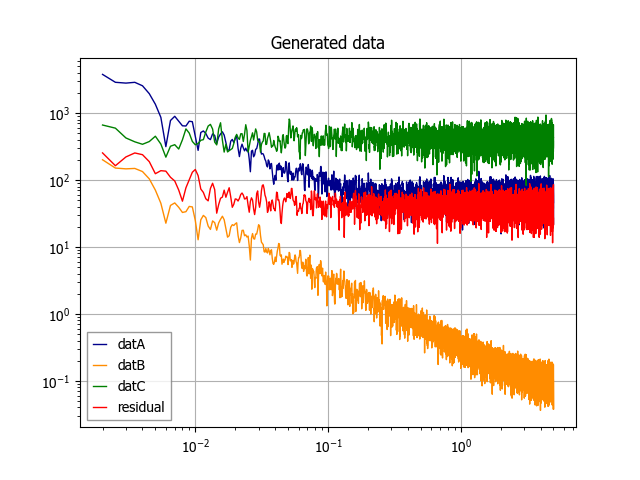

In [3]:
# just generate some data. make them correlated so that we test the entire method.
datres = np.cumsum(st.norm.rvs(size=50000))+100*st.norm.rvs(size=50000)
datB = 0.5*np.cumsum(st.norm.rvs(size=50000))
datC = 1000*st.norm.rvs(size=50000)
datA = datres+19*datB+0.10*datC

datres_true = lambda f: np.sqrt((1*10*np.sqrt(2/10)/(2*np.pi*f))**2 + (100*np.sqrt(2/10)*f**0)**2)
datB_true = lambda f: 0.5*10*np.sqrt(2/10)/(2*np.pi*f)
datC_true = lambda f: 1000*np.sqrt(2/10)*f**0
datA_true = lambda f: np.sqrt((datres_true(f))**2 + (19*datB_true(f))**2 + (0.10*datC_true(f))**2)
meas = [datA,datB,datC]

#calculate welch for comparison
PSDfres,PSDvres = sig.welch(datres,fs=10,window='blackmanharris',nperseg=20000)
PSDfA,PSDvA = sig.welch(datA,fs=10,window='blackmanharris',nperseg=20000)
PSDfB,PSDvB = sig.welch(datB,fs=10,window='blackmanharris',nperseg=20000)
PSDfC,PSDvC = sig.welch(datC,fs=10,window='blackmanharris',nperseg=20000)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1,label='datA')
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1,label='datB')
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1,label='datC')
ax.loglog(PSDfres[4:],np.sqrt(PSDvres[4:]),lw=1,c='r',label='residual')
ax.grid()
ax.legend()
ax.set_title('Generated data')
plt.show()

In [10]:
#calculate with WOSA method, for instance
meas_WOSAmethod = nf.CPSD_WOSAmethod(ts=meas,fs=10,nperseg=20000,win=nf.specwindows.BH92,verbose=True)

#extract parameters
meas_WOSAmethod.cohere
meas_WOSAmethod.CPSD
meas_WOSAmethod.PSD
meas_WOSAmethod.freqs
meas_WOSAmethod.Ls
meas_WOSAmethod.kcoeffs
meas_WOSAmethod.matp
meas_WOSAmethod.navs
meas_WOSAmethod.win
meas_WOSAmethod.winscheme

**** CPSD_WOSAmethod init verbose ****
This object contains the CPSD evaluated with the Welch scheme:
linearly-spaced frequencies, with spacing 0.0005Hz.
You can access CPSD with getCPSD(), or access the PSD with getPSD().
You can perform noise projection with the class noiseproj, giving this object as parameter.
Be aware that, given the amount of frequencies, calculations may take a lot of time.
            


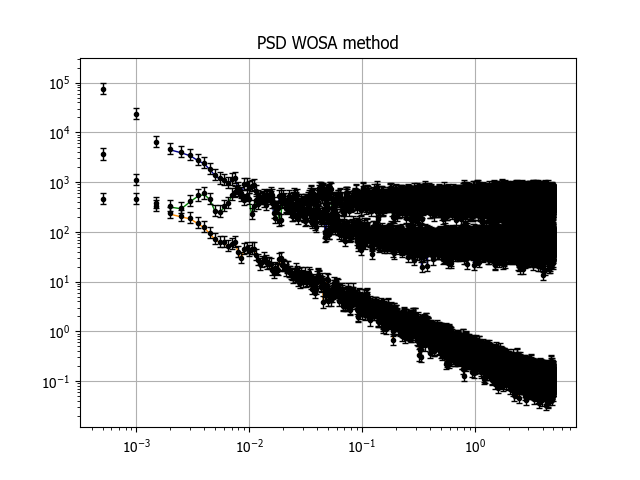

In [5]:
#extract quantiles
meas_WOSAmethod_PSDq = meas_WOSAmethod.PSDquantiles_eval(cval=0.68)

fig,ax=plt.subplots()
ax.loglog(PSDfA[4:],np.sqrt(PSDvA[4:]),lw=1)
ax.loglog(PSDfB[4:],np.sqrt(PSDvB[4:]),lw=1)
ax.loglog(PSDfC[4:],np.sqrt(PSDvC[4:]),lw=1)

tsidx = 0
ax.errorbar(meas_WOSAmethod.freqs,
            np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,0,:]),np.sqrt(meas_WOSAmethod_PSDq[tsidx,2,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
tsidx = 1
ax.errorbar(meas_WOSAmethod.freqs,
            np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,0,:]),np.sqrt(meas_WOSAmethod_PSDq[tsidx,2,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
tsidx = 2
ax.errorbar(meas_WOSAmethod.freqs,
            np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:]),
            yerr = [np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,0,:]),np.sqrt(meas_WOSAmethod_PSDq[tsidx,2,:])-np.sqrt(meas_WOSAmethod_PSDq[tsidx,1,:])],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.')
ax.grid()
ax.set_title('PSD WOSA method')
plt.show()

In [6]:
#same goes for MSC between two ts and R2

meas_WOSAmethod_MSCq_AB = meas_WOSAmethod.MSCquantiles_eval(idx1=0,idx2=1,cval=0.68)
meas_WOSAmethod_MSCq_AC = meas_WOSAmethod.MSCquantiles_eval(idx1=0,idx2=2,cval=0.68)
meas_WOSAmethod_MSCq_BC = meas_WOSAmethod.MSCquantiles_eval(idx1=1,idx2=2,cval=0.68)
meas_WOSAmethod_R2q = meas_WOSAmethod.R2quantiles_eval(cval=0.68)
meas_WOSAmethod_R2q95 = meas_WOSAmethod.R2quantiles_eval(cval=0.95)


MSCABtrue = lambda f: (19*datB_true(f)/datA_true(f))**2
MSCACtrue = lambda f: (0.1*datC_true(f)/datA_true(f))**2
MSCBCtrue = lambda f: 0*f
R2true = lambda f: 1-(datres_true(f)/datA_true(f))**2
faxis=np.logspace(-3,1,1000)

fig,ax=plt.subplots(2,1,figsize=(8,7),sharex=True)
ax[0].errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_MSCq_AB[:,1],
            yerr = [meas_WOSAmethod_MSCq_AB[:,1]-meas_WOSAmethod_MSCq_AB[:,0],meas_WOSAmethod_MSCq_AB[:,2]-meas_WOSAmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC AB')
ax[0].plot(faxis,MSCABtrue(faxis),c='C0')
ax[0].errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_MSCq_AC[:,1],
            yerr = [meas_WOSAmethod_MSCq_AC[:,1]-meas_WOSAmethod_MSCq_AC[:,0],meas_WOSAmethod_MSCq_AC[:,2]-meas_WOSAmethod_MSCq_AC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C1',fmt='.',label='MSC AC')
ax[0].plot(faxis,MSCACtrue(faxis),c='C1')
ax[0].errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_MSCq_BC[:,1],
            yerr = [meas_WOSAmethod_MSCq_BC[:,1]-meas_WOSAmethod_MSCq_BC[:,0],meas_WOSAmethod_MSCq_BC[:,2]-meas_WOSAmethod_MSCq_BC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C2',fmt='.',label='MSC BC')
ax[0].plot(faxis,MSCBCtrue(faxis),c='C2')
ax[0].grid()
ax[0].set_xscale('log')
ax[0].set_ylim([0,1])
ax[0].set_title('MSC WOSA method')
ax[0].legend()


ax[1].errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_R2q[:,1],
            yerr = [meas_WOSAmethod_R2q[:,1]-meas_WOSAmethod_R2q[:,0],meas_WOSAmethod_R2q[:,2]-meas_WOSAmethod_R2q[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='R2 68%')
ax[1].errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_R2q95[:,1],
            yerr = [meas_WOSAmethod_R2q95[:,1]-meas_WOSAmethod_R2q95[:,0],meas_WOSAmethod_R2q95[:,2]-meas_WOSAmethod_R2q95[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',alpha=0.5,label='R2 95%')
ax[1].plot(faxis,R2true(faxis),c='k')
ax[1].grid()
ax[1].set_xscale('log')
ax[1].set_ylim([0,1])
ax[1].set_title('R2 WOSA method')
ax[1].legend()
plt.show()

KeyboardInterrupt: 

In [ ]:
# what if I want to make a nice violinplot? For instance, of MSC A-C.

#first, get the posteriors
MSCaxis = np.linspace(1e-6,1-1e-6,500)
MSCpost_AC = meas_WOSAmethod.MSCposterior_eval(MSCaxis,idx1=0,idx2=2)
MSCpost_AB = meas_WOSAmethod.MSCposterior_eval(MSCaxis,idx1=0,idx2=1)

#PDFs are normalized, but we need them with fixed amplitude.
MSCpost_AC = [rho2post/np.max(rho2post) for rho2post in MSCpost_AC]
MSCpost_AB = [rho2post/np.max(rho2post) for rho2post in MSCpost_AB]

def violinplotter(f,PDFs,ax,violinwidth=0.15,**kwargs):
    # Plot each PDF as a mirrored violin
    for i in range(len(f)):
        logx = np.log10(f[i])
        vw = f[i+1]/f[i]-1 if i==0 else f[i]/f[i-1]-1 if i==len(f)-1 else min(f[i]/f[i-1]-1,f[i+1]/f[i]-1)
        scaled_pdf = PDFs[i] * vw * violinwidth  # Width in log-space
        left = logx - scaled_pdf
        right = logx + scaled_pdf

        # Back to linear space for plotting
        left_lin = 10**left
        right_lin = 10**right
        # Draw symmetrical violin around frequency
        ax.fill_betweenx(MSCaxis, left_lin, right_lin,**kwargs)
    return

fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_MSCq_AC[:,1],
            yerr = [meas_WOSAmethod_MSCq_AC[:,1]-meas_WOSAmethod_MSCq_AC[:,0],meas_WOSAmethod_MSCq_AC[:,2]-meas_WOSAmethod_MSCq_AC[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C1',fmt='.',label='MSC AC')
ax.plot(faxis,MSCACtrue(faxis),c='C1')
violinplotter(f=meas_WOSAmethod.freqs,PDFs=MSCpost_AC,ax=ax,
              facecolor='darkorange', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_MSCq_AB[:,1],
            yerr = [meas_WOSAmethod_MSCq_AB[:,1]-meas_WOSAmethod_MSCq_AB[:,0],meas_WOSAmethod_MSCq_AB[:,2]-meas_WOSAmethod_MSCq_AB[:,1]],
            linestyle='',capsize=2.5,lw=1,c='C0',fmt='.',label='MSC AB')
ax.plot(faxis,MSCABtrue(faxis),c='C0')
violinplotter(f=meas_WOSAmethod.freqs,PDFs=MSCpost_AB,ax=ax, 
              facecolor='C0', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.grid()
ax.set_xscale('log')
ax.set_ylim([0,1])
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
#R2 violin plot
R2post = meas_WOSAmethod.R2posterior_eval(MSCaxis)
#PDFs are normalized, but we need them with fixed amplitude.
R2post = [R2/np.max(R2) for R2 in R2post]

fig,ax=plt.subplots(figsize=(8,4))
ax.errorbar(x=meas_WOSAmethod.freqs,
            y=meas_WOSAmethod_R2q[:,1],
            yerr = [meas_WOSAmethod_R2q[:,1]-meas_WOSAmethod_R2q[:,0],meas_WOSAmethod_R2q[:,2]-meas_WOSAmethod_R2q[:,1]],
            linestyle='',capsize=2.5,lw=1,c='k',fmt='.',label='R2 68%')

violinplotter(f=meas_WOSAmethod.freqs,PDFs=R2post,ax=ax, 
              facecolor='k', alpha=0.3, edgecolor=None, linewidth=0.5)

ax.plot(faxis,R2true(faxis),c='k')
ax.grid()
ax.set_xscale('log')
ax.set_ylim([0,1])
ax.set_title('R2 violin')
ax.legend()
plt.show()